# Tarea 1. Compensación de iluminación y detección de personas

**Procesamiento de Imágenes — Universidad Diego Portales**

Las imágenes de la base DARK FACE son escenas nocturnas reales: casi toda la información
vive en un puñado de niveles bajos. Sobre ellas se aplican distintas técnicas de mejora de
contraste y se mide el efecto con un detector de personas (YOLO), que es una de las formas de
evaluar el realce cuando no existe una imagen de referencia con la exposición correcta.

Cada método clásico se ejecuta en dos variantes: aplicando la transformación a **cada canal
BGR por separado** (`bgr=True`) o solo sobre el **canal de luminancia** (`bgr=False`). Parte
del trabajo es decidir cuál conviene, y con qué criterio se decide eso.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Preparación del entorno

In [1]:
# En Colab / entorno limpio, comentar una vez instalado y clonado el repo.
!pip install -q ultralytics
!git clone -q https://github.com/Li-Chongyi/Zero-DCE.git

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch

# Puede activar el uso de la GPU para hacer inferencias rápidas de las redes neuronales.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("dispositivo:", DEVICE)

# --- rutas de las bases de datos, dejo mi ruta como ejemplo. Dentro de la ruta está la carpeta people.
BASE        = "/content/drive/MyDrive/Procesamiento de Imágenes/clases listas/clase 5"
PATH_PEOPLE = os.path.join(BASE, "people")                   # DARK FACE (sin referencia)
PATH_ZDCE   = os.path.join(BASE, "Zero-DCE/Zero-DCE_code")   # repositorio de Zero-DCE

# --- parámetros de la tarea -------------------------------------------------
GAMMA     = 0.4      # exponente de la transformación de potencia
PCT_LO    = 5        # percentil inferior del estiramiento
PCT_HI    = 95       # percentil superior del estiramiento
CONF_YOLO = 0.5      # confianza mínima para aceptar una detección

fatal: destination path 'Zero-DCE' already exists and is not an empty directory.
dispositivo: cpu


## 1. Funciones auxiliares

In [22]:
# Importe aqui las funciones auxiliares escritas en un archivo llamado funciones.py dentro de una carpeta llamada utils.
import importlib
import funciones

funciones = importlib.reload(funciones)

from funciones import (
    histograma,
    triptico,
    mostrar,
    niveles_usados,
    entropia,
    mostrar_histogramas,
    gamma_transformation,
    estiramiento_min_max,
    estiramiento_lo_hi,
    ecualizacion_histograma,
    ecualizacion_clahe,
)

## 2. Zero-DCE

Zero-DCE no predice la imagen realzada: predice **curvas de ajuste** que se aplican de
forma iterativa a cada píxel. Es decir, aprende LUTs, pero una por píxel y por iteración,
en vez de una sola para toda la imagen. Son unos 79 mil parámetros.

Ojo con el orden de canales: la red espera **RGB** normalizado a [0, 1], no BGR.

In [3]:
import importlib.util, glob

# Busca model.py: primero en PATH_ZDCE, si no, donde haya quedado el clon
candidatos = ([os.path.join(PATH_ZDCE, "model.py")] +
              glob.glob("**/Zero-DCE_code/model.py", recursive=True) +
              glob.glob("/content/**/Zero-DCE_code/model.py", recursive=True))
candidatos = [c for c in candidatos if os.path.isfile(c)]
assert candidatos, "no encuentro model.py; revisa dónde quedó el clon de Zero-DCE"

PATH_ZDCE  = os.path.abspath(os.path.dirname(candidatos[0]))
PESOS_ZDCE = os.path.join(PATH_ZDCE, "snapshots", "Epoch99.pth")
assert os.path.isfile(PESOS_ZDCE), f"faltan los pesos en {PESOS_ZDCE}"
print("usando:", PATH_ZDCE)

_spec = importlib.util.spec_from_file_location("zdce_model", os.path.join(PATH_ZDCE, "model.py"))
zdce_model = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(zdce_model)

_dce_net = None

def cargar_zero_dce(pesos=None):
    """Carga los pesos preentrenados una sola vez."""
    global _dce_net
    if _dce_net is None:
        net = zdce_model.enhance_net_nopool()
        estado = torch.load(pesos or PESOS_ZDCE, map_location="cpu")
        estado = {k.replace("module.", ""): v for k, v in estado.items()}
        net.load_state_dict(estado)
        _dce_net = net.eval().to(DEVICE)
    return _dce_net


@torch.no_grad()
def zero_dce(img, bgr=None):
    """Realce con Zero-DCE. Entra y sale BGR uint8.

    El argumento bgr se ignora: la red procesa la imagen completa y no admite la
    distinción entre 'por canal' y 'solo luminancia'.
    """
    net = cargar_zero_dce()
    rgb = cv2.cvtColor(np.ascontiguousarray(img), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    x = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    _, realzada, _ = net(x)
    out = realzada.squeeze(0).permute(1, 2, 0).clamp(0, 1).cpu().numpy()
    out = cv2.cvtColor((out * 255).round().astype(np.uint8), cv2.COLOR_RGB2BGR)
    return out

print("parámetros de la red:", sum(p.numel() for p in cargar_zero_dce().parameters()))

usando: /Users/benjaminzunigapueller/Desktop/ProcesaientoDeImagenes/Tareas/Tarea 1/Zero-DCE/Zero-DCE_code
parámetros de la red: 79416


## 3. Detector de personas

YOLOv8 con `classes=[0]` (clase *person* de COCO) y confianza mínima 0.5. Se registran el
número de detecciones **y la confianza media**: el conteo es un entero pequeño que salta de
forma brusca, mientras que la confianza media se mueve de manera mucho más suave.

`cv2.imread` entrega BGR y Ultralytics asume BGR cuando recibe un arreglo de NumPy, así que
la imagen se pasa directamente, sin invertir canales.

In [4]:
from ultralytics import YOLO

modelo_yolo = YOLO("yolov8n.pt")     # se descarga solo la primera vez


def detectar_personas(img, conf=CONF_YOLO, dibujar=True):
    """Detecta personas. Devuelve (n_detecciones, confianza_media, imagen_anotada)."""
    res = modelo_yolo(img, classes=[0], conf=conf, verbose=False)[0]
    confianzas = res.boxes.conf.cpu().numpy()

    anotada = None
    if dibujar:
        anotada = img.copy()
        cajas = res.boxes.xyxy.cpu().numpy().astype(int)
        for (x1, y1, x2, y2), c in zip(cajas, confianzas):
            cv2.rectangle(anotada, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(anotada, f"{c:.2f}", (x1, max(y1 - 6, 12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)

    media = float(confianzas.mean()) if len(confianzas) else 0.0
    return len(confianzas), media, anotada

### A.1 Inspección de una imagen

Antes de correr todo, elige una una imagen, despliégala y revisa su histograma. Anota en qué rango de niveles vive
la información y qué fracción de píxeles está pegada a los extremos.

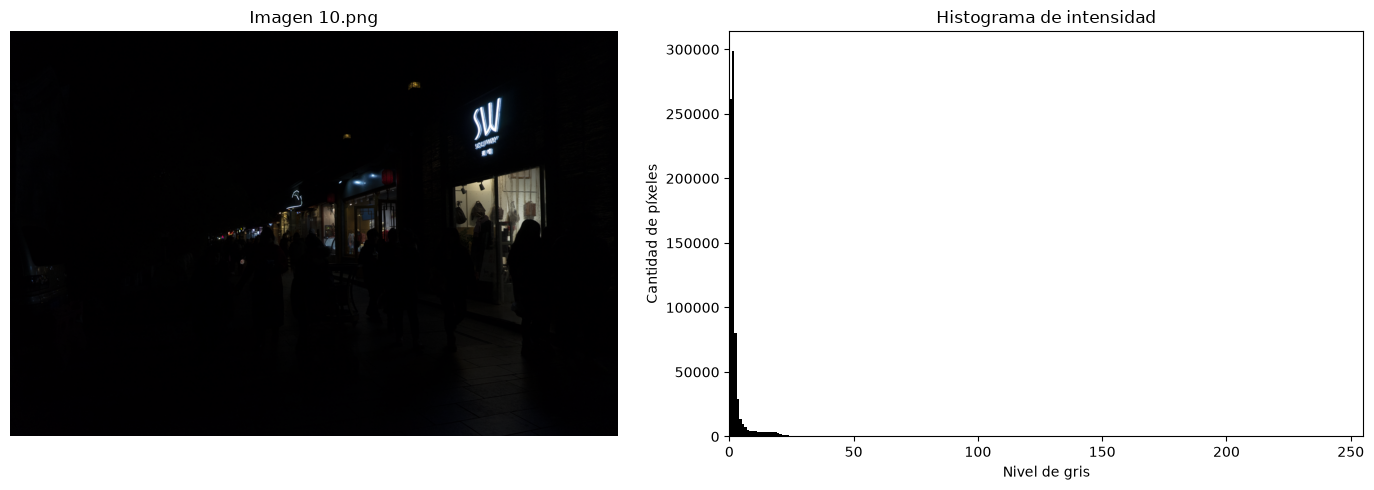

In [8]:
# Seleccionamos la imagen 10.png de la carpeta people.
RUTA_IMAGEN = os.path.join(PATH_PEOPLE, "10.png")
if not os.path.isfile(RUTA_IMAGEN):
    RUTA_IMAGEN = os.path.join("people", "10.png")

imagen = cv2.imread(RUTA_IMAGEN)
assert imagen is not None, f"no se pudo cargar la imagen: {RUTA_IMAGEN}"

imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(imagen_rgb)
plt.title("Imagen 10.png")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(imagen_gris.ravel(), bins=256, range=(0, 256), color="black")
plt.title("Histograma de intensidad")
plt.xlabel("Nivel de gris")
plt.ylabel("Cantidad de píxeles")
plt.xlim(0, 255)
plt.tight_layout()
plt.show()

**resp:** Esta imagen al ser muy oscura, se puede ver que la mayoria de los pixeles se encuentra en un rango de 0 a aproximadamente 40 de 255.

### A.2 Efecto de cada método sobre la imagen de ejemplo

Para la imagen escogida, compara las dos variantes de cada método. Fíjate especialmente en la dominante de color de
la escena y en qué le pasa con cada variante. Inclute Zero-DCE

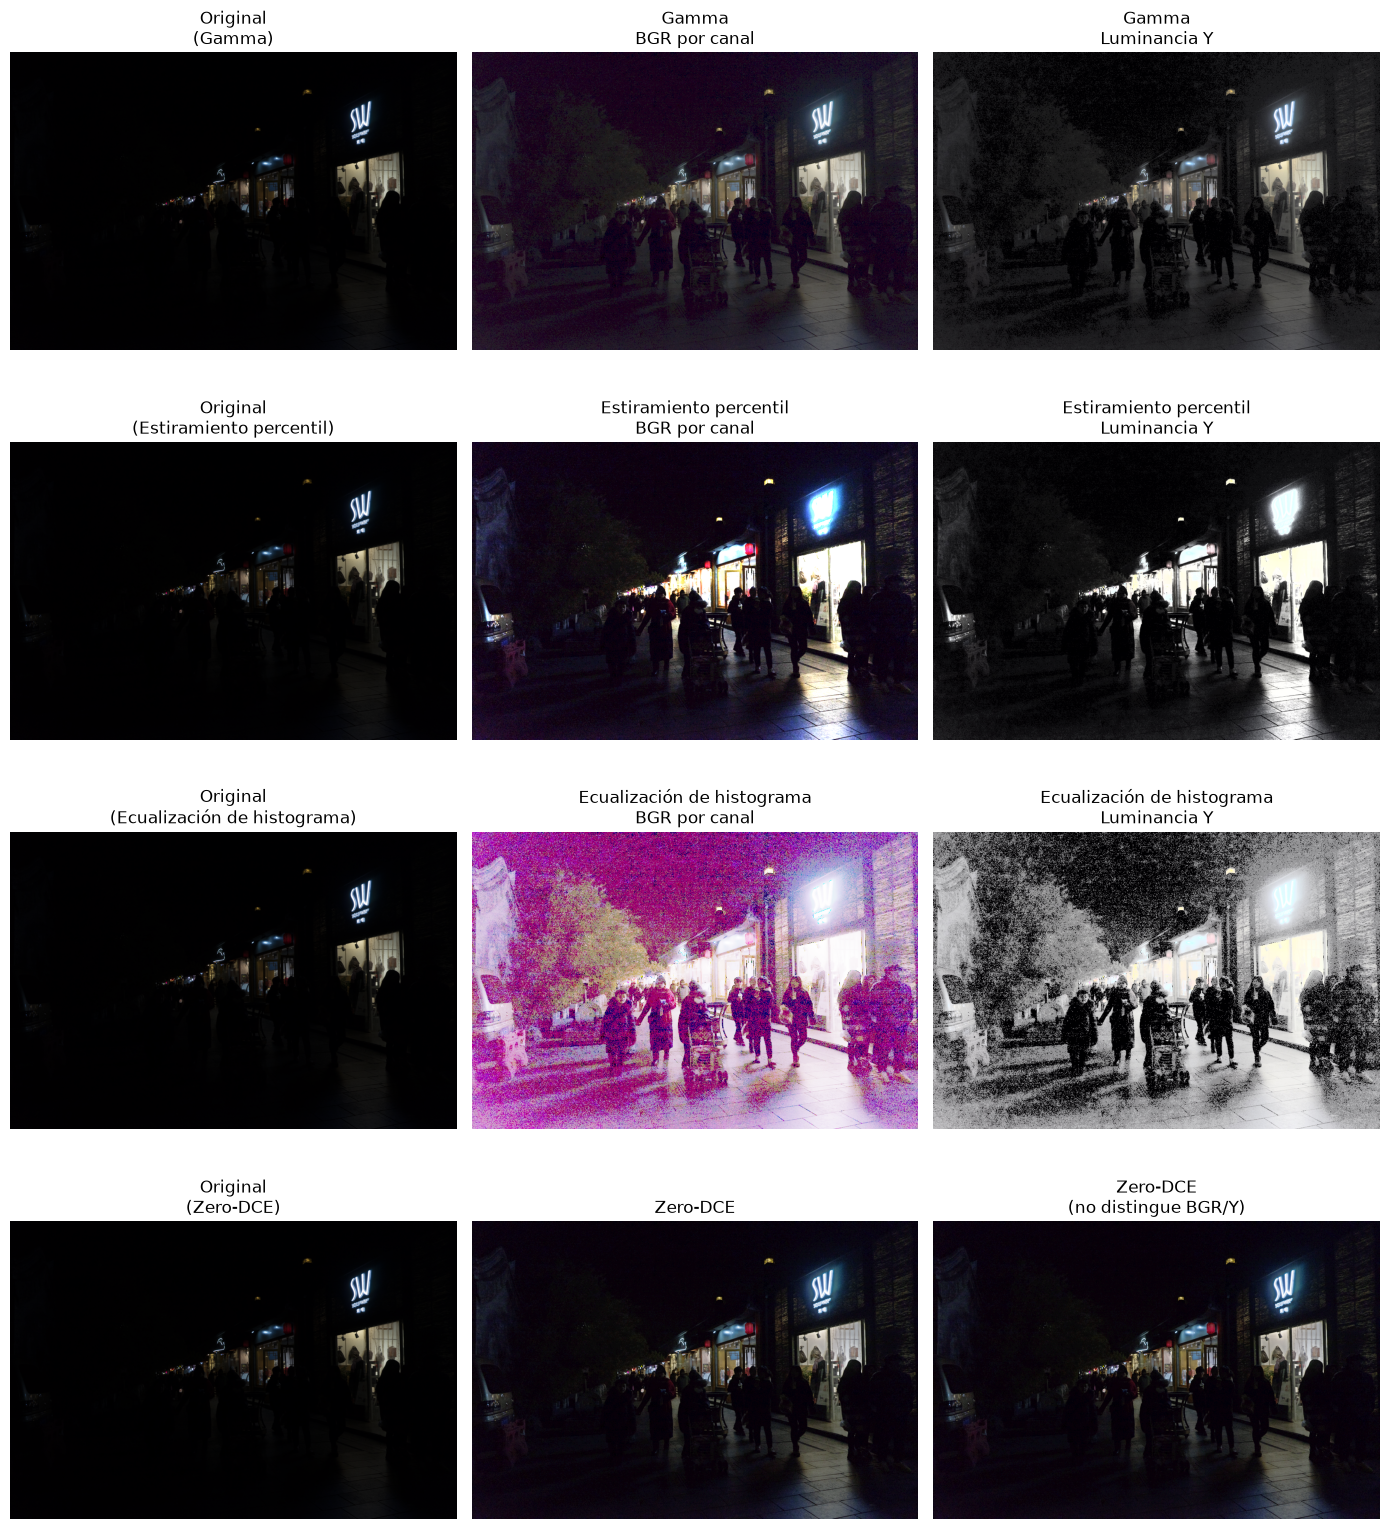

In [18]:
def aplicar_por_variante(img, transformacion, bgr=True):
    """Aplica una transformación por canal BGR o sobre el canal de luminancia Y."""
    if bgr:
        return transformacion(img)

    ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    ycrcb[:, :, 0] = transformacion(ycrcb[:, :, 0])
    return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)


def transformar_gamma(img, gamma=GAMMA):
    tabla = np.array(
        [((nivel / 255.0) ** gamma) * 255 for nivel in np.arange(256)],
        dtype=np.uint8,
    )
    return cv2.LUT(img, tabla)


def transformar_estiramiento_min_max(img):
    inferior = float(np.min(img))
    superior = float(np.max(img))
    if superior <= inferior:
        return img.copy()
    tabla = np.clip(
        (np.arange(256, dtype=np.float32) - inferior) * 255.0 / (superior - inferior),
        0,
        255,
    ).astype(np.uint8)
    return cv2.LUT(img, tabla)


def transformar_estiramiento(img, pct_lo=PCT_LO, pct_hi=PCT_HI):
    inferior, superior = np.percentile(img, (pct_lo, pct_hi))
    if superior <= inferior:
        return img.copy()
    tabla = np.clip(
        (np.arange(256, dtype=np.float32) - inferior) * 255.0 / (superior - inferior),
        0,
        255,
    ).astype(np.uint8)
    return cv2.LUT(img, tabla)


def ecualizar_canal(canal):
    histograma_canal = np.bincount(canal.ravel(), minlength=256)
    acumulado = histograma_canal.cumsum()
    niveles_presentes = histograma_canal > 0
    minimo = acumulado[niveles_presentes][0]
    total = canal.size
    if total == minimo:
        return canal.copy()
    tabla = np.round((acumulado - minimo) * 255.0 / (total - minimo))
    return cv2.LUT(canal, np.clip(tabla, 0, 255).astype(np.uint8))


def transformar_ecualizacion(img):
    if img.ndim == 2:
        return ecualizar_canal(img)
    return cv2.merge([ecualizar_canal(canal) for canal in cv2.split(img)])


def transformar_clahe(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    if img.ndim == 2:
        return clahe.apply(img)
    return cv2.merge([clahe.apply(canal) for canal in cv2.split(img)])


metodos = {
    "Gamma": transformar_gamma,
    "Estiramiento percentil": transformar_estiramiento,
    "Ecualización de histograma": transformar_ecualizacion,
}

fig, ejes = plt.subplots(4, 3, figsize=(14, 16))
for fila, (nombre, transformacion) in enumerate(metodos.items()):
    variantes = [
        imagen,
        aplicar_por_variante(imagen, transformacion, bgr=True),
        aplicar_por_variante(imagen, transformacion, bgr=False),
    ]
    titulos = [
        f"Original\n({nombre})",
        f"{nombre}\nBGR por canal",
        f"{nombre}\nLuminancia Y",
    ]
    for eje, resultado, titulo in zip(ejes[fila], variantes, titulos):
        eje.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
        eje.set_title(titulo)
        eje.axis("off")

resultado_zero_dce = zero_dce(imagen)
for eje, resultado, titulo in zip(
    ejes[3],
    [imagen, resultado_zero_dce, resultado_zero_dce],
    ["Original\n(Zero-DCE)", "Zero-DCE", "Zero-DCE\n(no distingue BGR/Y)"],
):
    eje.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    eje.set_title(titulo)
    eje.axis("off")

plt.tight_layout()
plt.show()

### A.3 Visaliza la función de transformación.

Usando la imagen escogida, visualiza la imagen resultante, la función de transformación y el histograma del canal Y de YCbCr. Comenta cada resultado. Usa la función tríptico vista en clase, adaptando lo necesario.

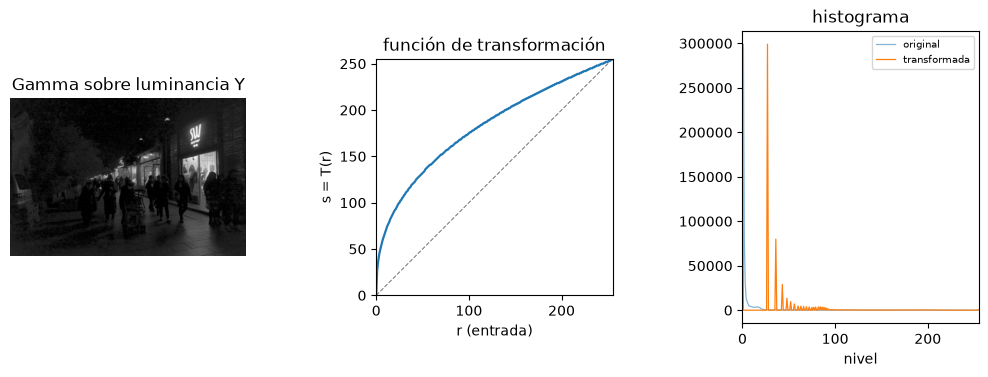

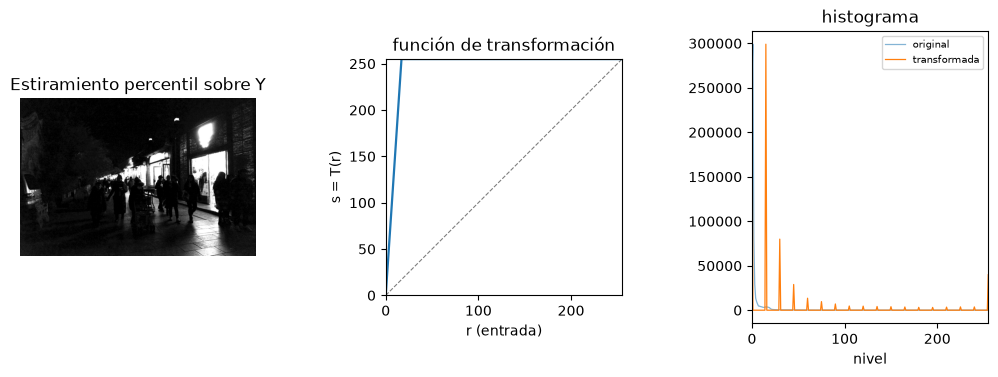

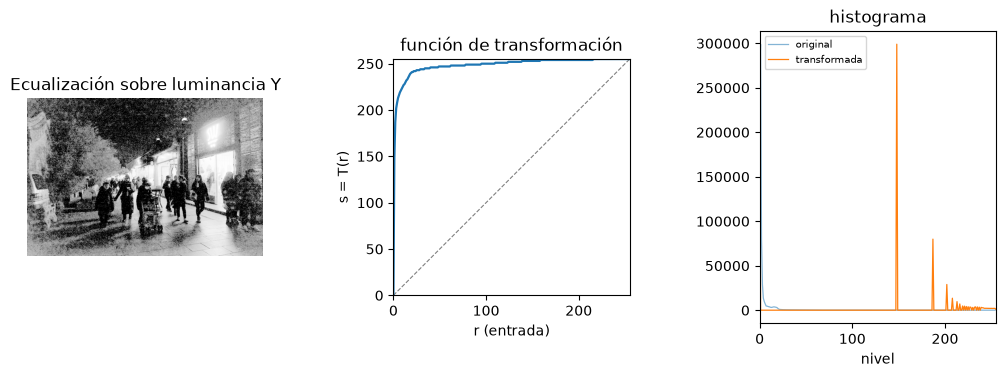

In [16]:
# Paso 1: extraemos el canal Y (luminancia) de la imagen en formato YCrCb.
y_original = cv2.cvtColor(imagen, cv2.COLOR_BGR2YCrCb)[:, :, 0]

# Paso 2: construimos la LUT de gamma y aplicamos la transformación al canal Y.
lut_gamma = np.array(
    [((nivel / 255.0) ** GAMMA) * 255 for nivel in np.arange(256)],
    dtype=np.uint8,
)
y_gamma = cv2.LUT(y_original, lut_gamma)

# Paso 3: construimos la LUT de estiramiento usando los percentiles definidos.
inferior, superior = np.percentile(y_original, (PCT_LO, PCT_HI))
if superior > inferior:
    lut_estiramiento = np.clip(
        (np.arange(256, dtype=np.float32) - inferior) * 255.0 / (superior - inferior),
        0,
        255,
    ).astype(np.uint8)
else:
    lut_estiramiento = np.arange(256, dtype=np.uint8)
y_estiramiento = cv2.LUT(y_original, lut_estiramiento)

# Paso 4: construimos la LUT de ecualización a partir del histograma acumulado.
hist = np.bincount(y_original.ravel(), minlength=256)
cdf = hist.cumsum()
cdf_min = cdf[hist > 0][0]
lut_ecualizacion = np.round(
    (cdf - cdf_min) * 255.0 / (cdf[-1] - cdf_min)
).clip(0, 255).astype(np.uint8)
y_ecualizada = cv2.LUT(y_original, lut_ecualizacion)

# Paso 5: triptico muestra resultado, LUT y comparación de histogramas.
triptico(y_original, y_gamma, lut_gamma, "Gamma sobre luminancia Y")
triptico(y_original, y_estiramiento, lut_estiramiento, "Estiramiento percentil sobre Y")
triptico(y_original, y_ecualizada, lut_ecualizacion, "Ecualización sobre luminancia Y")

### A.4 Detección sobre todas las imágenes

Se recorre la base completa, se aplica cada método en sus dos variantes y se detectan
personas. Las imágenes anotadas se guardan en `resultados/parte_a/` como parte de los entregables. Muestre la tabla en formato de pandas

In [23]:
# A.4: tabla completa de detecciones con confianza mínima 0.5.
from pathlib import Path

ruta_base = Path(PATH_PEOPLE)
if not ruta_base.is_dir():
    ruta_base = Path("people")
rutas_imagenes = sorted(
    [ruta for ruta in ruta_base.iterdir() if ruta.suffix.lower() in {".png", ".jpg", ".jpeg"}],
    key=lambda ruta: int(ruta.stem) if ruta.stem.isdigit() else ruta.stem,
)
assert rutas_imagenes, f"no se encontraron imágenes en {ruta_base}"

ruta_resultados = Path("resultados") / "parte_a"
ruta_resultados.mkdir(parents=True, exist_ok=True)
transformaciones = {
    "Gamma γ = 0.4 (BGR)": (gamma_transformation, {"gamma": GAMMA, "bgr": True}),
    "Gamma γ = 0.4 (Y)": (gamma_transformation, {"gamma": GAMMA, "bgr": False}),
    "Estiramiento min-max (BGR)": (estiramiento_min_max, {"bgr": True}),
    "Estiramiento min-max (Y)": (estiramiento_min_max, {"bgr": False}),
    "Estiramiento 5-95 (BGR)": (estiramiento_lo_hi, {"lo": PCT_LO, "hi": PCT_HI, "bgr": True}),
    "Estiramiento 5-95 (Y)": (estiramiento_lo_hi, {"lo": PCT_LO, "hi": PCT_HI, "bgr": False}),
    "Ecualización (BGR)": (ecualizacion_histograma, {"bgr": True}),
    "Ecualización (Y)": (ecualizacion_histograma, {"bgr": False}),
    "CLAHE (BGR)": (ecualizacion_clahe, {"bgr": True}),
    "CLAHE (Y)": (ecualizacion_clahe, {"bgr": False}),
}
nombres_metodos = ["Imagen original", *transformaciones.keys(), "Zero-DCE"]
conteos = {nombre: [] for nombre in nombres_metodos}
nombres_imagenes = []

for ruta in rutas_imagenes:
    imagen_actual = cv2.imread(str(ruta))
    nombres_imagenes.append(ruta.name)

    cantidad, _, anotada = detectar_personas(imagen_actual, conf=CONF_YOLO, dibujar=True)
    conteos["Imagen original"].append(cantidad)
    carpeta = ruta_resultados / "Imagen_original"
    carpeta.mkdir(exist_ok=True)
    cv2.imwrite(str(carpeta / ruta.name), anotada)

    for nombre, (transformacion, parametros) in transformaciones.items():
        resultado, _ = transformacion(imagen_actual, **parametros)
        cantidad, _, anotada = detectar_personas(resultado, conf=CONF_YOLO, dibujar=True)
        conteos[nombre].append(cantidad)
        carpeta = ruta_resultados / nombre.replace(" ", "_").replace("γ", "gamma")
        carpeta.mkdir(exist_ok=True)
        cv2.imwrite(str(carpeta / ruta.name), anotada)

    resultado = zero_dce(imagen_actual)
    cantidad, _, anotada = detectar_personas(resultado, conf=CONF_YOLO, dibujar=True)
    conteos["Zero-DCE"].append(cantidad)
    carpeta = ruta_resultados / "Zero-DCE"
    carpeta.mkdir(exist_ok=True)
    cv2.imwrite(str(carpeta / ruta.name), anotada)

tabla_conteos = pd.DataFrame(conteos, index=nombres_imagenes).T
tabla_conteos["TOTAL"] = tabla_conteos.sum(axis=1)
tabla_conteos.sort_values("TOTAL", ascending=False)

,0.png,1.png,2.png,10.png,17.png,18.png,31.png,94.png,96.png,TOTAL
Gamma γ = 0.4 (BGR),4,5,8,8,8,9,7,5,9,63
Zero-DCE,5,5,8,8,7,9,7,3,9,61
Estiramiento 5-95 (BGR),5,3,8,9,7,8,7,3,10,60
Ecualización (Y),3,5,9,7,7,7,7,4,9,58
Estiramiento 5-95 (Y),5,4,7,7,6,9,7,3,8,56
Ecualización (BGR),2,4,9,6,7,8,6,4,10,56
Gamma γ = 0.4 (Y),2,5,5,7,8,8,7,4,8,54
CLAHE (Y),3,4,7,6,7,9,7,2,6,51
CLAHE (BGR),2,3,7,6,7,9,7,2,6,49
Estiramiento min-max (Y),1,3,7,2,5,6,7,2,3,36


### A.5 Detección sobre todas las imágenes

Construya una segunda tabla con la misma estructura, pero registrando la confianza media de las detecciones en lugar del conteo (0 si no hubo ninguna detección). La última columna corresponde al promedio de las confianzas. Muestre los resultados en orden descendente. Muestre la tabla en formato de pandas

In [ ]:
# A.5: tabla de confianza media con confianza mínima 0.5.
confianzas_metodos = {nombre: [] for nombre in nombres_metodos}

for ruta in rutas_imagenes:
    imagen_actual = cv2.imread(str(ruta))
    _, confianza, _ = detectar_personas(imagen_actual, conf=CONF_YOLO, dibujar=False)
    confianzas_metodos["Imagen original"].append(confianza)

    for nombre, (transformacion, parametros) in transformaciones.items():
        resultado, _ = transformacion(imagen_actual, **parametros)
        _, confianza, _ = detectar_personas(resultado, conf=CONF_YOLO, dibujar=False)
        confianzas_metodos[nombre].append(confianza)

    resultado = zero_dce(imagen_actual)
    _, confianza, _ = detectar_personas(resultado, conf=CONF_YOLO, dibujar=False)
    confianzas_metodos["Zero-DCE"].append(confianza)

tabla_confianzas = pd.DataFrame(confianzas_metodos, index=nombres_imagenes).T
tabla_confianzas["PROMEDIO"] = tabla_confianzas.mean(axis=1)
tabla_confianzas.sort_values("PROMEDIO", ascending=False).round(4)

,0.png,1.png,2.png,10.png,17.png,18.png,31.png,94.png,96.png,PROMEDIO
Ecualización (BGR),0.6909,0.6686,0.6597,0.7043,0.7170,0.6788,0.6825,0.6451,0.6759,0.6803
Ecualización (Y),0.6788,0.6648,0.6440,0.7388,0.7244,0.7021,0.6718,0.5947,0.6762,0.6773
Estiramiento 5-95 (BGR),0.6141,0.6831,0.6918,0.7046,0.7085,0.6777,0.6769,0.6429,0.6564,0.6729
Estiramiento 5-95 (Y),0.5744,0.7040,0.6887,0.7162,0.7188,0.6437,0.6745,0.6424,0.6912,0.6726
CLAHE (BGR),0.6090,0.7009,0.6965,0.6652,0.6759,0.6489,0.6794,0.6699,0.6888,0.6705
Gamma γ = 0.4 (Y),0.5898,0.6661,0.7346,0.7024,0.6721,0.6758,0.6704,0.6186,0.6744,0.6671
Zero-DCE,0.5901,0.6302,0.6756,0.7023,0.7102,0.6789,0.6847,0.6372,0.6797,0.6654
Gamma γ = 0.4 (BGR),0.5791,0.6496,0.6594,0.7035,0.6919,0.6994,0.6851,0.6103,0.6807,0.6621
CLAHE (Y),0.6045,0.6700,0.6771,0.6636,0.6633,0.6440,0.6750,0.6640,0.6871,0.6610
Imagen original,0.5497,0.6758,0.6729,0.5201,0.6661,0.5831,0.6199,0.5732,0.6734,0.6149


### A.6 Sensibilidad al umbral

Repita la tabla 1 con una confianza mínima de 0.25 y compare el orden de los métodos con el obtenido a 0.5. Analice si hay consistencia entre los métodos variando el umbral.  

In [ ]:
# A.6: repetimos la tabla de detecciones con confianza mínima 0.25.
CONF_UMBRAL_BAJO = 0.25
conteos_025 = {nombre: [] for nombre in nombres_metodos}

for ruta in rutas_imagenes:
    imagen_actual = cv2.imread(str(ruta))
    cantidad, _, _ = detectar_personas(imagen_actual, conf=CONF_UMBRAL_BAJO, dibujar=False)
    conteos_025["Imagen original"].append(cantidad)

    for nombre, (transformacion, parametros) in transformaciones.items():
        resultado, _ = transformacion(imagen_actual, **parametros)
        cantidad, _, _ = detectar_personas(resultado, conf=CONF_UMBRAL_BAJO, dibujar=False)
        conteos_025[nombre].append(cantidad)

    resultado = zero_dce(imagen_actual)
    cantidad, _, _ = detectar_personas(resultado, conf=CONF_UMBRAL_BAJO, dibujar=False)
    conteos_025["Zero-DCE"].append(cantidad)

tabla_conteos_025 = pd.DataFrame(conteos_025, index=nombres_imagenes).T
tabla_conteos_025["TOTAL"] = tabla_conteos_025.sum(axis=1)
tabla_conteos_025 = tabla_conteos_025.sort_values("TOTAL", ascending=False)
display(tabla_conteos_025)

comparacion_umbrales = pd.DataFrame({
    "Total_0.5": tabla_conteos["TOTAL"],
    "Posición_0.5": tabla_conteos["TOTAL"].rank(ascending=False, method="min").astype(int),
    "Total_0.25": tabla_conteos_025["TOTAL"],
    "Posición_0.25": tabla_conteos_025["TOTAL"].rank(ascending=False, method="min").astype(int),
})
comparacion_umbrales["Cambio de posición"] = (
    comparacion_umbrales["Posición_0.25"] - comparacion_umbrales["Posición_0.5"]
)
comparacion_umbrales.sort_values("Posición_0.25")

Tabla con umbral 0.25


,0.png,1.png,2.png,10.png,17.png,18.png,31.png,94.png,96.png,TOTAL
Estiramiento 5-95 (BGR),9,9,14,9,15,20,10,14,13,113
Estiramiento 5-95 (Y),8,6,17,8,17,20,10,13,11,110
Ecualización (BGR),10,8,14,9,15,21,8,13,11,109
Zero-DCE,8,9,14,11,15,19,8,13,12,109
Gamma γ = 0.4 (BGR),8,8,15,12,14,16,8,11,12,104
CLAHE (BGR),6,9,13,11,16,18,8,11,12,104
Gamma γ = 0.4 (Y),10,9,14,12,12,14,9,12,11,103
CLAHE (Y),8,9,13,9,15,15,8,13,12,102
Ecualización (Y),8,8,15,9,13,13,8,11,10,95
Imagen original,4,6,14,9,5,15,8,4,6,71


,Total_0.5,Posición_0.5,Total_0.25,Posición_0.25,Cambio de posición
Estiramiento 5-95 (BGR),60,3,113,1,-2
Estiramiento 5-95 (Y),56,5,110,2,-3
Ecualización (BGR),56,5,109,3,-2
Zero-DCE,61,2,109,3,1
CLAHE (BGR),49,9,104,5,-4
Gamma γ = 0.4 (BGR),63,1,104,5,4
Gamma γ = 0.4 (Y),54,7,103,7,0
CLAHE (Y),51,8,102,8,0
Ecualización (Y),58,4,95,9,5
Estiramiento min-max (BGR),34,11,71,10,-1
